## 각 데이터셋별로 train, validation, test 데이터셋 분리 (user_id 기준)

In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

def tr_val_test_split(df):
    # 1개 이하만 존재하는 클래스는 train set에 포함
    class_counts = df['label'].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    stratify_df = df[df['label'].isin(valid_classes)]

    rare_df = df[~df['label'].isin(valid_classes)]

    train_df, tmp_df = train_test_split(stratify_df, test_size=0.2, random_state=42, stratify=stratify_df['label'])
    train_df = pd.concat([train_df, rare_df], ignore_index=True)

    try:
        val_df, test_df = train_test_split(tmp_df, test_size=0.5, stratify=tmp_df['label'], random_state=42)
    except ValueError as e:
        tmp_class_counts = tmp_df['label'].value_counts()
        tmp_valid_classes = tmp_class_counts[tmp_class_counts >= 2].index
        tmp_stratify_df = tmp_df[tmp_df['label'].isin(tmp_valid_classes)]

        tmp_rare_df = tmp_df[~tmp_df['label'].isin(tmp_valid_classes)]

        val_df, test_df = train_test_split(tmp_stratify_df, test_size=0.2, random_state=42, stratify=tmp_stratify_df['label'])
        val_df = pd.concat([val_df, tmp_rare_df], ignore_index=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    counts = [train_df['label'].value_counts().sort_index(), val_df.value_counts('label').sort_index(), test_df.value_counts('label').sort_index()]
    
    for i, ax in enumerate(axes):
        counts[i].plot(kind='bar', ax=ax)
        ax.set_title(['Train', 'Validation', 'Test'][i])
        ax.set_xlabel('label')
        ax.set_ylabel('count')
    plt.tight_layout()
    
    plt.show()

    return train_df, val_df, test_df

In [51]:
def get_sector_path(row):
    for sector in SECTORS:
        if row[sector] == -1:
            row[f"{sector}_path"] = ""
        else:
            path = f"034_data/{row['user_id']}/{sector}_{row['filename']}"
            if os.path.exists(os.path.join('/home/hocheol/inskin_ai/no_track/datasets/wrinkle_data/v0.3/v0.3_data', path)):
                row[f"{sector}_path"] = path
            else:
                row[f"{sector}_path"] = ""
    
    return row

In [57]:
from utils.constants import SECTORS
import os
import json
import pandas as pd

label_path = '/home/hocheol/inskin_ai/no_track/datasets/wrinkle_data/labels/wrinkle-260219_034.csv'

origin_df = pd.read_csv(label_path).iloc[:, :-1]
filtered_df = origin_df[~origin_df.iloc[:, 1:].isna().all(axis=1)].reset_index(drop=True)
filtered_df.rename(columns={'periroal': 'perioral'}, inplace=True)
filtered_df.fillna(-1, inplace=True)
filtered_df = filtered_df.astype({col: int for col in SECTORS})
filtered_df['user_id'] = filtered_df['filename'].apply(lambda x: x.split('_')[0])
filtered_df = filtered_df[['filename', 'user_id', *SECTORS]]
filtered_df = filtered_df.apply(get_sector_path, axis=1)
filtered_df = filtered_df[['user_id', 'filename', 'forehead_path','right_eye_path','left_eye_path','nasolabial_path','perioral_path','right_vol_path','left_vol_path', 'forehead', 'right_eye', 'left_eye', 'nasolabial', 'perioral', 'right_vol', 'left_vol']]
# origin_df = pd.read_json(os.path.join(label_dir, 'wrinkle_labels.json'), orient='records', dtype={'user_id':str, })
filtered_df['label'] = filtered_df.apply(lambda x:x.loc[SECTORS[:]].mean(), axis=1).round().astype(int)
user_split = filtered_df.loc[:, ['user_id', 'label']].drop_duplicates(ignore_index=True)
# filtered_df
user_split
check = len(user_split['user_id']) == len(user_split['user_id'].unique())
print(f"user_id가 unique하게 존재하는가???? : {check} - {len(user_split['user_id'])} vs {len(user_split['user_id'].unique())}")
if not check:
    print('\nbefore')
    print(user_split['label'].value_counts())
    ## label의 max값으로 unique하게 만들기
    user_split = user_split.sort_values(by='label', ascending=False).drop_duplicates(subset=['user_id'], ignore_index=True)
    print('\nafter')
    print(user_split['label'].value_counts())
    check = len(user_split['user_id']) == len(user_split['user_id'].unique())
    print(f"이제는? : {check} - {len(user_split['user_id'])} vs {len(user_split['user_id'].unique())}")

user_id가 unique하게 존재하는가???? : False - 2042 vs 1968

before
label
1    796
0    698
2    464
3     81
4      3
Name: count, dtype: int64

after
label
1    777
0    646
2    461
3     81
4      3
Name: count, dtype: int64
이제는? : True - 1968 vs 1968


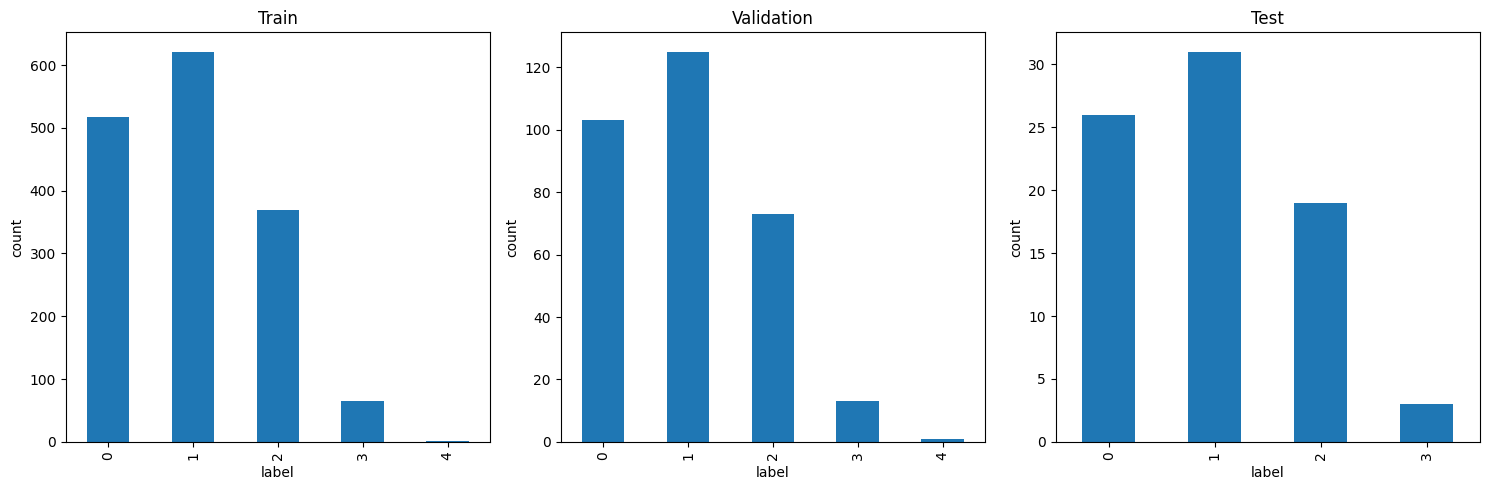

In [58]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [59]:
train_df['label'].value_counts(), val_df['label'].value_counts(), test_df['label'].value_counts()

(label
 1    621
 0    517
 2    369
 3     65
 4      2
 Name: count, dtype: int64,
 label
 1    125
 0    103
 2     73
 3     13
 4      1
 Name: count, dtype: int64,
 label
 1    31
 0    26
 2    19
 3     3
 Name: count, dtype: int64)

In [60]:
split_train = pd.merge(train_df, filtered_df, on='user_id', how='left').sort_values(by=['user_id'])
split_val = pd.merge(val_df, filtered_df, on='user_id', how='left').sort_values(by=['user_id'])
split_test = pd.merge(test_df, filtered_df, on='user_id', how='left').sort_values(by=['user_id'])

In [61]:
split_train.drop(columns=['label_x', 'label_y'], inplace=True)
split_val.drop(columns=['label_x', 'label_y'], inplace=True)
split_test.drop(columns=['label_x', 'label_y'], inplace=True)

In [62]:
# user_id로 교집합을 구하여 중복된 user_id의 수를 확인

len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [65]:
import json
# split_train.to_json(os.path.join(label_dir, 'wrinkle_train.json'), orient='records', force_ascii=True, indent=2)
# split_val.to_json(os.path.join(label_dir, 'wrinkle_val.json'), orient='records', force_ascii=False, indent=2)
# split_test.to_json(os.path.join(label_dir, 'wrinkle_test.json'), orient='records', force_ascii=False, indent=2)

label_dir = '/home/hocheol/inskin_ai/no_track/datasets/wrinkle_data/v0.3/v0.3.0/034_data/label'

os.makedirs(label_dir, exist_ok=True)

with open(os.path.join(label_dir, 'wrinkle_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, ensure_ascii=False, indent=2)
with open(os.path.join(label_dir, 'wrinkle_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, ensure_ascii=False, indent=2)
with open(os.path.join(label_dir, 'wrinkle_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, ensure_ascii=False, indent=2)

In [81]:
########################### v0.2의 라벨 가져오기

In [89]:
label_path

'/home/work/hocheol_dir/workspace/_dataset/datasets/wrinkle_data/v0.2/v0.2_data/028_data/label'

In [92]:
import json
import os

with open('/home/work/hocheol_dir/workspace/_dataset/datasets/wrinkle_data/v0.2/v0.2_data/wrinkle_label_paths.json', 'r') as f:
    label_paths = json.load(f)

for label_path in label_paths:
    new_label_path = label_path.replace('v0.2/v0.2_data', 'v0.3/v0.3.0')
    for step in ['train', 'val', 'test']:
        path = os.path.join(label_path, f"wrinkle_{step}.json")
        new_path = os.path.join(new_label_path, f"wrinkle_{step}.json")
        
        # print(os.path.exists(path))
        with open(path, 'r') as f:
            json_data = json.load(f)
        
        os.makedirs(os.path.dirname(new_path), exist_ok=True)
        with open(new_path, 'w') as f:
            json.dump(json_data, f, ensure_ascii=False, indent=2)